In [1]:
!pip install -q transformers

import os, gc, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()

In [11]:
from transformers import ViTForImageClassification, ViTImageProcessor

MODEL_NAME = "google/vit-base-patch16-224"  # ImageNet-1k finetuned, patch=16, 224px -> 14x14=196 patches

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
vit_base_model = ViTForImageClassification.from_pretrained(MODEL_NAME, output_attentions=True, output_hidden_states=True)
vit_base_model.eval()

vit_base_model = vit_base_model.to(device)

n_params = sum(p.numel() for p in vit_base_model.parameters())
print(f"Loaded {MODEL_NAME} | {n_params/1e6:.1f}M params | "
      f"{vit_base_model.config.num_hidden_layers} layers | "
      f"{vit_base_model.config.num_attention_heads} heads/layer")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loaded google/vit-base-patch16-224 | 86.6M params | 12 layers | 12 heads/layer


True ImageNet-1k indices: [0, 217, 482]


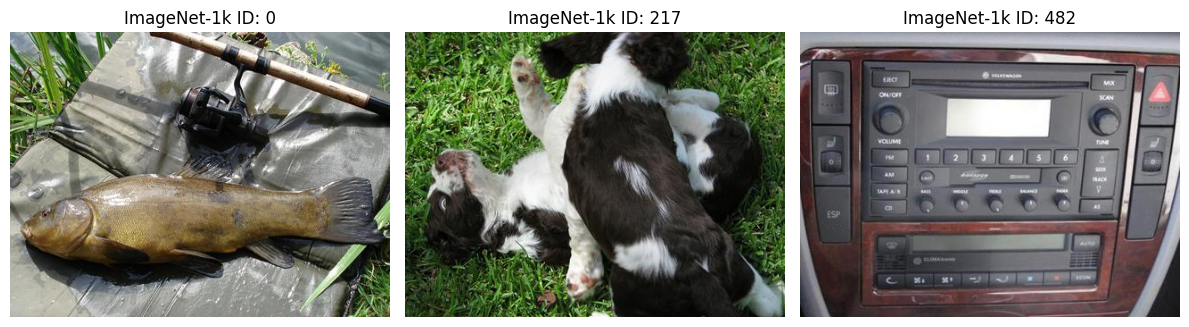

In [12]:
import matplotlib.pyplot as plt
from torchvision.datasets import Imagenette


IMAGENETTE_TO_IMAGENET1K = {
    "n01440764": 0, "n02102040": 217, "n02979186": 482, "n03000684": 491,
    "n03028079": 497, "n03394916": 566, "n03417042": 569, "n03425413": 571,
    "n03445777": 574, "n03888257": 701,
}

def get_unique_imagenette_samples(data_dir="./data", num_samples=3, image_size="320px"):
    dataset = Imagenette(root=data_dir, split="val", size=image_size, download=True)
    
    local_to_global = {
        local_idx: IMAGENETTE_TO_IMAGENET1K[wnid] 
        for wnid, local_idx in dataset.wnid_to_idx.items()
    }

    selected_samples = []
    seen_labels = set()
    
    for img, local_label in dataset:
        if local_label not in seen_labels:
            global_label = local_to_global[local_label]
            selected_samples.append((img.convert("RGB"), global_label))
            seen_labels.add(local_label)
            
        if len(selected_samples) == num_samples:
            break
            
    return selected_samples

def plot_samples(samples):
    num_samples = len(samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
    
    if num_samples == 1:
        axes = [axes]
        
    for ax, (img, label) in zip(axes, samples):
        ax.imshow(img)
        ax.set_title(f"ImageNet-1k ID: {label}")
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    samples = get_unique_imagenette_samples(data_dir="./dataset", num_samples=3)
    
    true_labels = [label for _, label in samples]
    print(f"True ImageNet-1k indices: {true_labels}")
    
    plot_samples(samples)
    images = [img for img, _ in samples]

In [13]:
inputs = processor(images=images, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)

print("pixel_values.shape:", pixel_values.shape)  #(B, 3, 224, 224)
patch_size = vit_base_model.config.patch_size
img_size = vit_base_model.config.image_size
n_patches_per_side = img_size // patch_size
n_patches = n_patches_per_side ** 2
print(f"patch_size={patch_size}, image_size={img_size} -> "
      f"{n_patches_per_side}x{n_patches_per_side} = {n_patches} patches "
      f"+ 1 CLS token = seq_len {n_patches + 1}")

pixel_values.shape: torch.Size([3, 3, 224, 224])
patch_size=16, image_size=224 -> 14x14 = 196 patches + 1 CLS token = seq_len 197


Image 0: true='tench, Tinca tinca', pred='tench, Tinca tinca', conf=1.000
Image 1: true='English springer, English springer spaniel', pred='English springer, English springer spaniel', conf=0.806
Image 2: true='cassette player', pred='cassette player', conf=0.423


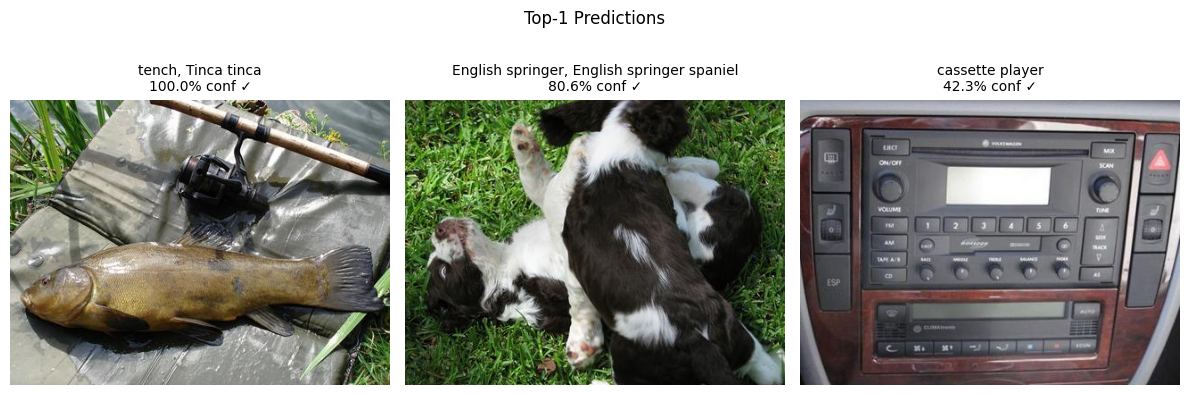

In [14]:
def evaluate_and_plot_predictions(model, pixel_values, original_images, true_labels, save_path="./predictions.png"):

    with torch.no_grad():
        outputs = model(
            pixel_values=pixel_values, 
            output_attentions=True, 
            output_hidden_states=True
        )

    probs = F.softmax(outputs.logits, dim=-1)
    confidences, predicted_indices = probs.max(dim=-1)
    
    id2label = model.config.id2label
    num_images = len(original_images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4.5))
    if num_images == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, original_images)):
        pred_idx = predicted_indices[i].item()
        conf = confidences[i].item()
        true_idx = true_labels[i]
        
        pred_label = id2label[pred_idx]
        true_label = id2label[true_idx]
        
        is_correct = pred_idx == true_idx
        mark = "✓" if is_correct else "✗"
        
        print(f"Image {i}: true={true_label!r}, pred={pred_label!r}, conf={conf:.3f}")
        
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{pred_label}\n{conf * 100:.1f}% conf {mark}", fontsize=10)

    plt.suptitle("Top-1 Predictions")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return outputs, predicted_indices

if __name__ == "__main__":
    outputs, top1_idx = evaluate_and_plot_predictions(
        model=vit_base_model, 
        pixel_values=pixel_values, 
        original_images=images, 
        true_labels=true_labels,
        save_path="./vit_classification_results.png"
    )

In [16]:
attentions = outputs.attentions
print(f"len(attentions) = {len(attentions)} (one per transformer block)")
print(f"attentions[-1].shape = {attentions[-1].shape} -> (batch, heads, seq_len, seq_len)")

len(attentions) = 12 (one per transformer block)
attentions[-1].shape = torch.Size([3, 12, 197, 197]) -> (batch, heads, seq_len, seq_len)


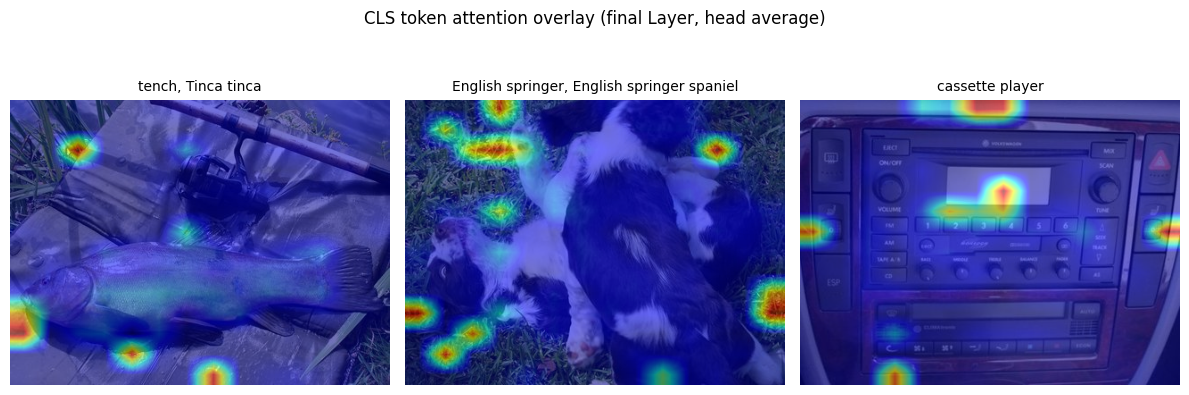

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_cls_attention_map(attn_final_layer, image_idx, grid_size):
    avg_heads = attn_final_layer[image_idx].mean(dim=0)

    #extracting CLS tokens attention
    cls_to_patches = avg_heads[0, 1:]
    #normalize
    cls_to_patches = cls_to_patches / cls_to_patches.sum()
    
    return cls_to_patches.reshape(grid_size, grid_size).cpu().numpy()

def overlay_attention(image, attn_map, ax, alpha=0.55):
    attn_normalized = (attn_map / attn_map.max() * 255).astype(np.uint8)
    attn_img = Image.fromarray(attn_normalized)
    attn_resized = attn_img.resize(image.size, resample=Image.BILINEAR)
    attn_array = np.array(attn_resized) / 255.0
    
    ax.imshow(image)
    ax.imshow(attn_array, cmap="jet", alpha=alpha)
    ax.axis("off")

def plot_attention_heatmaps(images, attentions, predicted_indices, id2label, grid_size, save_path="./attention_overlay.png"):
    final_layer_attn = attentions[-1]
    num_images = len(images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4.5))
    if num_images == 1:
        axes = [axes]
        
    for i, (ax, img) in enumerate(zip(axes, images)):
        amap = get_cls_attention_map(final_layer_attn, i, grid_size)
        overlay_attention(img, amap, ax)
        
        pred_label = id2label[predicted_indices[i].item()]
        ax.set_title(pred_label, fontsize=10)
        
    plt.suptitle("CLS token attention overlay (final Layer, head average)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

if __name__ == "__main__":
    plot_attention_heatmaps(
        images=images,
        attentions=outputs.attentions,
        predicted_indices=top1_idx,
        id2label=vit_base_model.config.id2label,
        grid_size=14, # standard for ViT-Base (224/16 = 14)
        save_path="./vit_attention_heatmaps.png"
    )

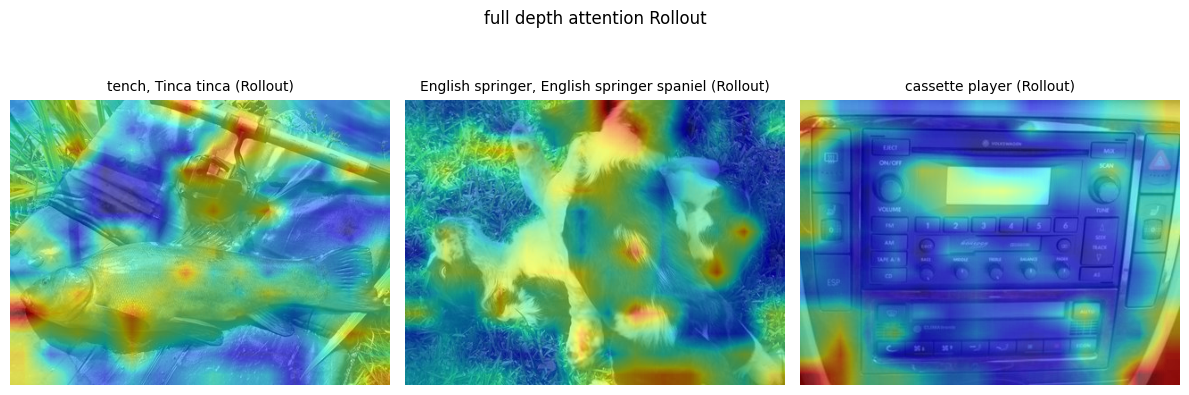

In [18]:
def get_single_head_attention_map(attention_matrix, grid_size):
    cls_attention = attention_matrix[0, 1:]
    cls_attention = cls_attention / cls_attention.sum()
    return cls_attention.reshape(grid_size, grid_size).cpu().numpy()

def plot_per_head_attention(image, final_layer_attn, label, num_heads, grid_size, save_path="./per_head_attention.png"):
    fig, axes = plt.subplots(2, num_heads//2, figsize=(2.2* (num_heads//2), 5))
    
    for head_idx, ax in enumerate(axes.flat):
        head_attention = final_layer_attn[head_idx]
        attn_map = get_single_head_attention_map(head_attention, grid_size)
        
        overlay_attention(image, attn_map, ax, alpha=0.6)
        ax.set_title(f"Head {head_idx}",fontsize=9)
        
    plt.suptitle(f"per head CLS Attention (Final Layer) — {label}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

def compute_entropy(tensor):
    tensor = tensor.clamp_min(1e-12)
    return -(tensor * tensor.log()).sum().item()

def plot_head_entropies(final_layer_attn, num_heads, save_path="./head_entropy.png"):
    entropies = []
    
    for head_idx in range(num_heads):
        head_weights = final_layer_attn[head_idx, 0, 1:]
        normalized_weights = head_weights / head_weights.sum()
        entropies.append(compute_entropy(normalized_weights))
        
    plt.figure(figsize=(6, 3.5))
    sns.barplot(x=list(range(num_heads)), y=entropies, palette="viridis")
    plt.xlabel("Head")
    plt.ylabel("attention entropy (nats)")
    plt.title("per head Focus (Lower = More Concentrated)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

def compute_attention_rollout(attentions, image_idx, grid_size):
    device = attentions[0].device
    seq_len = attentions[0].shape[-1]
    result = torch.eye(seq_len, device=device)
    
    for layer_attn in attentions:
        avg_head_attn = layer_attn[image_idx].mean(dim=0)
        avg_head_attn = avg_head_attn + torch.eye(seq_len, device=device)
        avg_head_attn = avg_head_attn / avg_head_attn.sum(dim=-1, keepdim=True)
        result = avg_head_attn @ result
        
    cls_rollout = result[0, 1:]
    cls_rollout = cls_rollout / cls_rollout.sum()
    
    return cls_rollout.reshape(grid_size, grid_size).cpu().numpy()

def plot_rollout_heatmaps(images, attentions, predicted_indices, id2label, grid_size, save_path="./attention_rollout.png"):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4.5))
    
    if num_images == 1:
        axes = [axes]
        
    for i, (ax, img) in enumerate(zip(axes, images)):
        rollout_map = compute_attention_rollout(attentions, i, grid_size)
        overlay_attention(img, rollout_map, ax)
        
        pred_label = id2label[predicted_indices[i].item()]
        ax.set_title(f"{pred_label} (Rollout)", fontsize=10)
        
    plt.suptitle("full depth attention Rollout")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
if __name__ == "__main__":
    # Example for the rollout heatmap
    plot_rollout_heatmaps(
        images=images, 
        attentions=outputs.attentions, 
        predicted_indices=top1_idx, 
        id2label=vit_base_model.config.id2label, 
        grid_size=14
    )

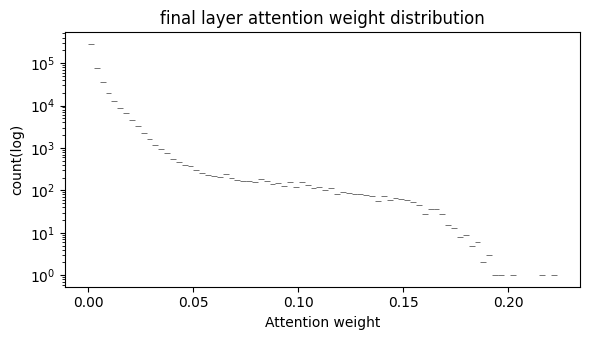

In [21]:
img_idx =0
final_layer_attn = outputs.attentions[-1]
weights = final_layer_attn[img_idx].flatten().detach().cpu().numpy()
plt.figure(figsize=(6, 3.5))
sns.histplot(weights, bins=80, log_scale=(False, True))
plt.xlabel("Attention weight"); plt.ylabel("count(log)")
plt.title("final layer attention weight distribution")
plt.tight_layout(); plt.savefig("/kaggle/working/nb1_attn_weight_hist.png", dpi=150)
plt.show()